In [60]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
# === CONFIGURATION ===
DATA_DIR = r"C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\data\cleaned_data\data_segment\outliers_removed_5features\steeringRemoved"  # ← change this

DERIV_THRESHOLD = 0.008             # threshold for steering detection

COLUMN_NAME = "SteeringInput"        # column to analyze
TIME_PER_SAMPLE = 0.02               # 20 ms = 0.02 seconds
N_SAMPLES = 501                      # total time points per participant
TIME_WINDOW = (-5.0, 5.0) # seconds for mapping indices to time

# Time axis centered around 0 (−5s to +5s)
time_axis = np.linspace(-5, 5, N_SAMPLES)


# # Fixed event order
event_order = [
    'StagEventNew', 'FallingRocksEventNew', 'FogEventNew',
    'MarketPlaceEvent', 'CyclistEvent', 'Panne',
    'GhostDriver', 'MotorcyclistEvent'
]
event_order = list(reversed(event_order))  # reverse order


# Threshold based


In [61]:
STEERING_THRESHOLD = 0.03  # absolute threshold (first movement > 5% of wheel)



✅ Steering Onset Summary per Event:
               event  mean_onset_s  median_onset_s  sd_onset_s  n_valid  n_total
   MotorcyclistEvent      1.700380            1.53    1.043057      158      158
         GhostDriver      2.881869            3.52    1.443090      107      160
               Panne      1.015497            1.10    0.936368      151      160
        CyclistEvent      2.174177            2.06    1.667980       79      159
    MarketPlaceEvent      1.153113            1.34    0.793627      151      157
         FogEventNew      2.171825            2.70    1.602780      137      160
FallingRocksEventNew      2.095497            2.18    1.429600      151      160
        StagEventNew      0.309875            0.00    0.574674      160      160

✅ Summary saved to: C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\data\cleaned_data\data_segment\outliers_removed_5features\steeringRemoved\steering_onset_summary.csv


C:\Users\erene\AppData\Local\Temp\ipykernel_19280\4058446313.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = all_onsets_df.groupby("event")["onset_s"].agg(['mean', 'median', 'std']).reset_index()


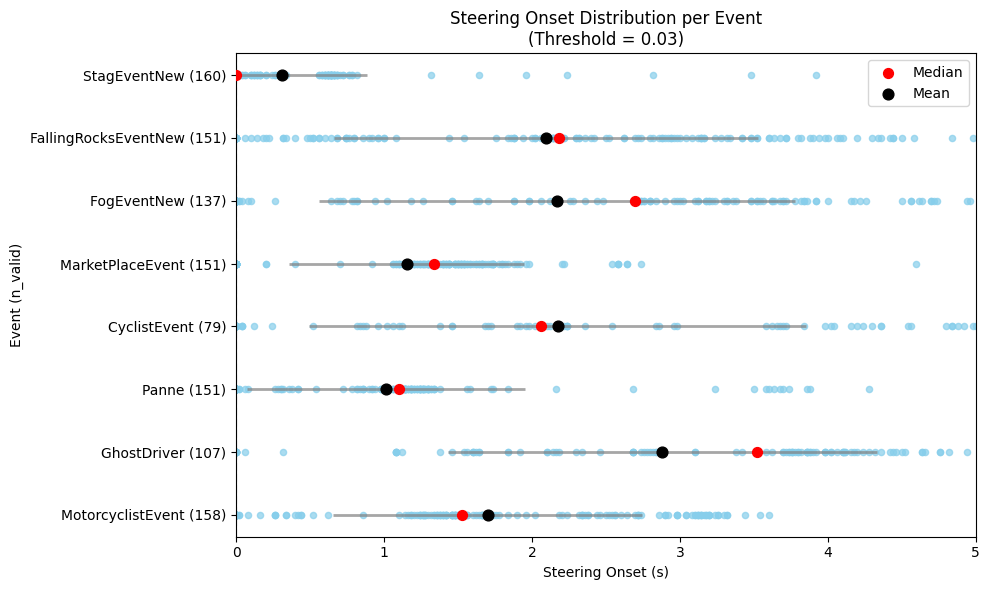

In [62]:
# ===== FUNCTIONS =====
def detect_steering_onset(steering_series, threshold=STEERING_THRESHOLD):
    """Detect first real steering movement based on absolute threshold."""
    onset_indices = np.where(np.abs(steering_series) >= threshold)[0]
    return onset_indices[0] if len(onset_indices) > 0 else np.nan

def extract_event_name(fname):
    """Extract event name between 'segment_around_' and '_nearest'."""
    match = re.search(r'segment_around_(.*?)_nearest', fname)
    return match.group(1) if match else fname

# ===== MAIN LOOP =====
summary = []
all_onsets = []

for fname in sorted(os.listdir(DATA_DIR)):
    if not (fname.startswith("segment_") and fname.endswith(".csv")):
        continue
    event_name = extract_event_name(fname)
    if event_name not in event_order:
        continue  # skip any event not in the fixed order

    fpath = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(fpath)

    if 'uid' not in df.columns or COLUMN_NAME not in df.columns:
        print(f"⚠️ Skipping {fname}: missing required columns.")
        continue

    event_onsets = []
    uid_counts = df['uid'].value_counts()
    n_total = len(uid_counts)

    for uid, subdf in df.groupby('uid'):
        steering = subdf[COLUMN_NAME].values
        onset_idx = detect_steering_onset(steering)

        if not np.isnan(onset_idx):
            time_axis_adjusted = np.linspace(-5, 5, len(steering))
            onset_time = time_axis_adjusted[int(onset_idx)]
        else:
            onset_time = np.nan

        event_onsets.append(onset_time)
        all_onsets.append({"event": event_name, "onset_s": onset_time})

    mean_onset = np.nanmean(event_onsets)
    median_onset = np.nanmedian(event_onsets)
    sd_onset = np.nanstd(event_onsets)
    n_valid = np.sum(~np.isnan(event_onsets))

    summary.append({
        "event": event_name,
        "mean_onset_s": mean_onset,
        "median_onset_s": median_onset,
        "sd_onset_s": sd_onset,
        "n_valid": n_valid,
        "n_total": n_total
    })

# ===== SUMMARY TABLE =====
summary_df = pd.DataFrame(summary)

# Enforce fixed event order
summary_df["event"] = pd.Categorical(summary_df["event"], categories=event_order, ordered=True)
summary_df = summary_df.sort_values("event").reset_index(drop=True)

print("\n✅ Steering Onset Summary per Event:")
print(summary_df.to_string(index=False))

# --- Save to CSV ---
summary_path = os.path.join(DATA_DIR, "steering_onset_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\n✅ Summary saved to: {summary_path}")

# ===== PLOTTING =====
all_onsets_df = pd.DataFrame(all_onsets)
all_onsets_df = all_onsets_df[all_onsets_df["event"].isin(event_order)]
all_onsets_df["event"] = pd.Categorical(all_onsets_df["event"], categories=event_order, ordered=True)

# --- Compute stats ---
stats = all_onsets_df.groupby("event")["onset_s"].agg(['mean', 'median', 'std']).reset_index()
stats = stats.merge(summary_df[['event', 'n_valid']], on='event')

# --- Labels and Y positions ---
stats['label'] = stats.apply(lambda r: f"{r['event']} ({int(r['n_valid'])})", axis=1)
event_to_y = {event: i for i, event in enumerate(stats['event'])}
all_onsets_df['y_pos'] = all_onsets_df['event'].map(event_to_y)

# --- Plot ---
plt.figure(figsize=(10, 6))

# Scatter raw onsets
plt.scatter(
    all_onsets_df['onset_s'],
    all_onsets_df['y_pos'],
    color='skyblue', s=20, alpha=0.7
)

# Mean (black), Median (red), SD whiskers
for idx, row in stats.iterrows():
    y = idx
    plt.hlines(
        y=y,
        xmin=row['mean'] - row['std'],
        xmax=row['mean'] + row['std'],
        colors='gray', linewidth=2, alpha=0.7
    )
    plt.scatter(row['median'], y, color='red', s=50, zorder=10, label='Median' if idx == 0 else "")
    plt.scatter(row['mean'], y, color='black', s=60, zorder=11, label='Mean' if idx == 0 else "")

plt.axvline(0, color='gray', linestyle='--')
plt.yticks(ticks=range(len(stats)), labels=stats['label'])
plt.xlabel("Steering Onset (s)")
plt.ylabel("Event (n_valid)")
plt.xlim(0, 5)
plt.title(f"Steering Onset Distribution per Event\n(Threshold = {STEERING_THRESHOLD})")
plt.legend()
plt.tight_layout()
plt.show()


# Derivatives

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === USER INPUT ===
DATA_FILE = r"C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\reaction_times.csv"   # path to your CSV file
EXCLUDE_UIDS = []     # <- enter UIDs you want to exclude, or leave empty []

# Fixed event order
event_order = [
    'StagEventNew', 
    'FallingRocksEventNew',  
    'MotorcyclistEvent'
]


In [68]:
# === LOAD DATA ===
df = pd.read_csv(DATA_FILE)

# Sanity check
required_cols = [
    "uid", "EventName", "RT_Steering",
    "RT_fastest_type", "RT_expected_type", "RT_expected"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Exclude UIDs if requested
if EXCLUDE_UIDS:
    df = df[~df["uid"].isin(EXCLUDE_UIDS)]
    print(f"Excluded {len(EXCLUDE_UIDS)} UIDs: {EXCLUDE_UIDS}")

# Restrict to only desired events
df = df[df["EventName"].isin(event_order)]
if df.empty:
    raise ValueError("No matching events found in data for the specified event_order.")

# === COMPUTE SUMMARY PER EVENT ===
summary = []

for event_name, subdf in df.groupby("EventName"):
    # RT_Steering stats
    mean_rt_steering = subdf["RT_Steering"].mean(skipna=True)
    median_rt_steering = subdf["RT_Steering"].median(skipna=True)
    sd_rt_steering = subdf["RT_Steering"].std(skipna=True)
    n_valid = subdf["RT_Steering"].notna().sum()

    # RT_expected stats
    mean_rt_expected = subdf["RT_expected"].mean(skipna=True)
    median_rt_expected = subdf["RT_expected"].median(skipna=True)
    sd_rt_expected = subdf["RT_expected"].std(skipna=True)

    # Fastest type counts and most frequent
    fastest_counts = subdf["RT_fastest_type"].value_counts(dropna=True)
    most_common_fastest = fastest_counts.idxmax() if not fastest_counts.empty else None
    n_fastest_types = {k: int(v) for k, v in fastest_counts.items()}

    # Expected type counts and most frequent
    expected_counts = subdf["RT_expected_type"].value_counts(dropna=True)
    most_common_expected = expected_counts.idxmax() if not expected_counts.empty else None
    n_expected_types = {k: int(v) for k, v in expected_counts.items()}

    summary.append({
        "Event": event_name,
        "Mean_RT_Steering": mean_rt_steering,
        "Median_RT_Steering": median_rt_steering,
        "SD_RT_Steering": sd_rt_steering,
        "n_valid": n_valid,
        "Mean_RT_Expected": mean_rt_expected,
        "Median_RT_Expected": median_rt_expected,
        "SD_RT_Expected": sd_rt_expected,
        "Most_Common_RT_Fastest_Type": most_common_fastest,
        "Fastest_Type_Counts": n_fastest_types,
        "Most_Common_RT_Expected_Type": most_common_expected,
        "Expected_Type_Counts": n_expected_types
    })

# === SAVE & DISPLAY SUMMARY ===
summary_df = pd.DataFrame(summary)

# Keep only rows in event_order and sort by that order
summary_df["Event"] = pd.Categorical(summary_df["Event"], categories=event_order, ordered=True)
summary_df = summary_df.sort_values("Event")

pd.set_option('display.max_colwidth', None)
print("\n=== Reaction Time Summary per Event ===")
print(summary_df.to_string(index=False))

summary_path = "reaction_time_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\n✅ Summary saved to '{summary_path}'")



=== Reaction Time Summary per Event ===
               Event  Mean_RT_Steering  Median_RT_Steering  SD_RT_Steering  n_valid  Mean_RT_Expected  Median_RT_Expected  SD_RT_Expected Most_Common_RT_Fastest_Type                                        Fastest_Type_Counts Most_Common_RT_Expected_Type                                       Expected_Type_Counts
        StagEventNew          0.885338            0.651258        1.273704      157          2.388886            2.536659        1.337345                 RT_Steering  {'RT_Steering': 152, 'RT_Brake': 4, 'RT_Acceleration': 1}                     RT_Brake {'RT_Brake': 96, 'RT_Steering': 48, 'RT_Acceleration': 13}
FallingRocksEventNew          2.520203            2.420868        1.620197      157          2.309495            2.054052        1.282300                 RT_Steering {'RT_Steering': 102, 'RT_Brake': 50, 'RT_Acceleration': 5}                     RT_Brake                        {'RT_Brake': 87, 'RT_Steering': 70}
   MotorcyclistEvent

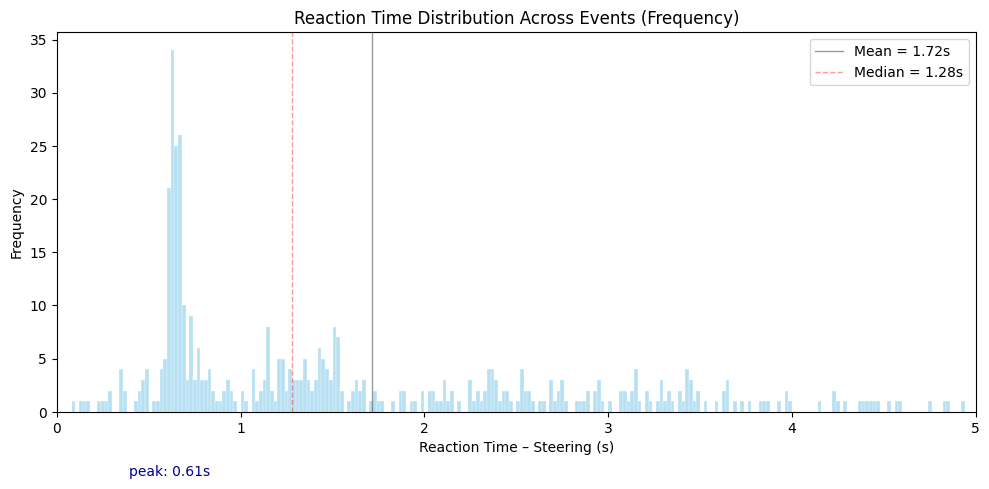

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Combine all RTs from all events
combined_rts = df[df["EventName"].isin(event_order)]["RT_Steering"].dropna()

# Compute histogram bins and frequencies to get the max frequency RT
counts, bin_edges = np.histogram(combined_rts, bins=40)
max_idx = np.argmax(counts)
max_freq_rt = (bin_edges[max_idx] + bin_edges[max_idx + 1]) / 2  # center of bin

# Compute summary stats
mean_rt = combined_rts.mean()
median_rt = combined_rts.median()
sd_rt = combined_rts.std()

plt.figure(figsize=(10, 5))

bins = np.linspace(0, 5, 251)  # 250 bins → 0.02s width

# --- Frequency histogram + smoothed KDE ---
sns.histplot(
    combined_rts,
    bins=bins,
    color='skyblue',
    stat='count',   # frequency on y-axis
    kde=False,
    alpha=0.6,
    edgecolor='white',

)

# --- Overlay mean ± SD line ---
plt.axvline(mean_rt, color='black', linestyle='-', linewidth=1, alpha=.4, label=f"Mean = {mean_rt:.2f}s")
plt.axvline(median_rt, color='red', linestyle='--', linewidth=1, alpha=.4,label=f"Median = {median_rt:.2f}s")
# --- Annotate max frequency ---
plt.text(
    max_freq_rt, -5,  # slightly below x-axis
    f"peak: {max_freq_rt:.2f}s",
    ha='center',
    va='top',
    fontsize=10,
    color='darkblue'
)

plt.xlabel("Reaction Time – Steering (s)")
plt.ylabel("Frequency")
plt.title("Reaction Time Distribution Across Events (Frequency)")
plt.xlim(0, 5)
plt.legend()
plt.tight_layout()
plt.show()


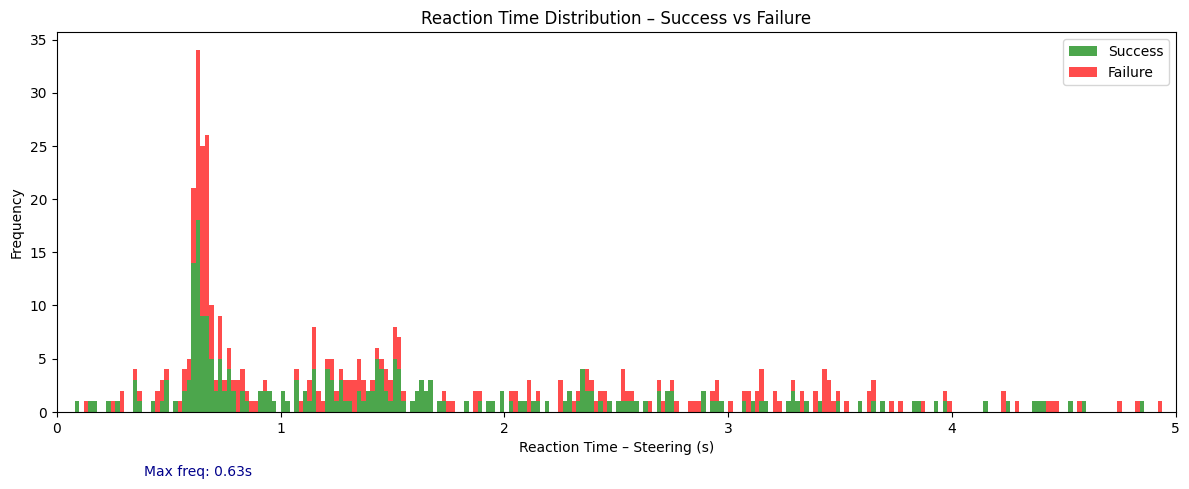

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Filter for relevant events and drop missing RTs
data = df[df["EventName"].isin(event_order)][["RT_Steering", "SuccessfulCompletionState"]].dropna()

# Split RTs
success_rts = data[data["SuccessfulCompletionState"] == 1]["RT_Steering"]
failure_rts = data[data["SuccessfulCompletionState"] == 0]["RT_Steering"]

# Define bins: 250 bins for 0–5s
bins = np.linspace(0, 5, 251)  # 250 bins → 0.02s width

# Compute histogram counts
success_counts, _ = np.histogram(success_rts, bins=bins)
failure_counts, _ = np.histogram(failure_rts, bins=bins)

# Plot stacked bars
plt.figure(figsize=(12, 5))
plt.bar(bins[:-1], success_counts, width=bins[1]-bins[0], color='green', alpha=0.7, label='Success', align='edge')
plt.bar(bins[:-1], failure_counts, width=bins[1]-bins[0], color='red', alpha=0.7, label='Failure', align='edge', bottom=success_counts)

# Annotate max frequency (overall)
total_counts = success_counts + failure_counts
max_idx = np.argmax(total_counts)
max_rt = (bins[max_idx] + bins[max_idx + 1]) / 2
plt.text(max_rt, -5, f"Max freq: {max_rt:.2f}s", ha='center', va='top', color='darkblue')

plt.xlabel("Reaction Time – Steering (s)")
plt.ylabel("Frequency")
plt.title("Reaction Time Distribution – Success vs Failure")
plt.xlim(0, 5)
plt.legend()
plt.tight_layout()
plt.show()


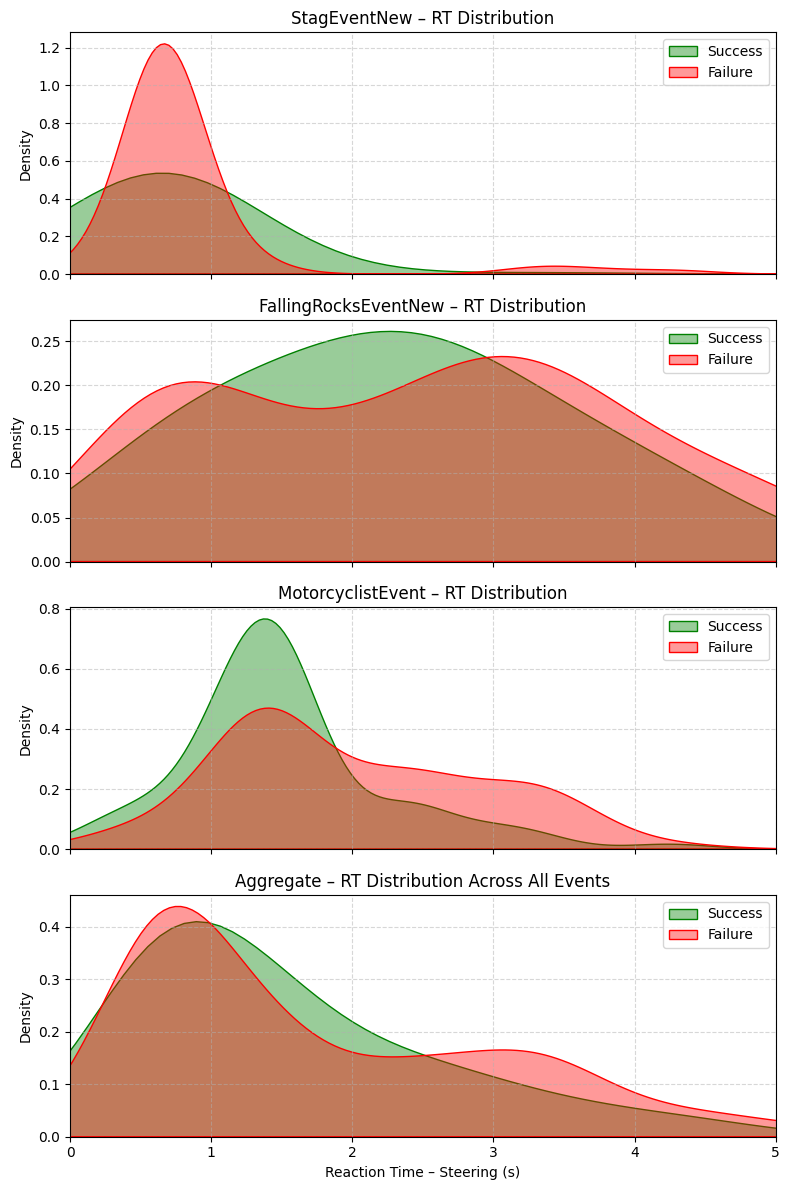

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out missing RTs

df_plot = df[df["EventName"].isin(event_order)].dropna(subset=["RT_Steering"])

# Add 1 for aggregate

n_events = len(event_order) + 1
fig, axes = plt.subplots(n_events, 1, figsize=(8, 3 * n_events), sharex=True)

# Plot each event separately

for i, event in enumerate(event_order):
    ax = axes[i]
    event_data = df_plot[df_plot["EventName"] == event]

    sns.kdeplot(
        data=event_data[event_data["SuccessfulCompletionState"] == 1],
        x="RT_Steering",
        fill=True,
        color="green",
        alpha=0.4,
        label="Success",
        ax=ax
    )
    sns.kdeplot(
        data=event_data[event_data["SuccessfulCompletionState"] == 0],
        x="RT_Steering",
        fill=True,
        color="red",
        alpha=0.4,
        label="Failure",
        ax=ax
    )

    ax.set_title(f"{event} – RT Distribution")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    # Aggregate plot (all events combined)

ax = axes[-1]
sns.kdeplot(
data=df_plot[df_plot["SuccessfulCompletionState"] == 1],
x="RT_Steering",
fill=True,
color="green",
alpha=0.4,
label="Success",
ax=ax
)
sns.kdeplot(
data=df_plot[df_plot["SuccessfulCompletionState"] == 0],
x="RT_Steering",
fill=True,
color="red",
alpha=0.4,
label="Failure",
ax=ax
)
ax.set_title("Aggregate – RT Distribution Across All Events")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

# Shared x-axis label

axes[-1].set_xlabel("Reaction Time – Steering (s)")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

In [99]:
import pandas as pd
from scipy.stats import ttest_ind

# Filter to events of interest
df_plot = df[df["EventName"].isin(event_order)].dropna(subset=["RT_Steering"])

results = []

# --- Per-event descriptives and t-tests ---
for event in event_order:
    event_data = df_plot[df_plot["EventName"] == event]
    
    # Split success vs failure
    success = event_data[event_data["SuccessfulCompletionState"] == 1]["RT_Steering"]
    failure = event_data[event_data["SuccessfulCompletionState"] == 0]["RT_Steering"]
    
    # Descriptive stats
    desc = {
        "Event": event,
        "Success_N": len(success),
        "Success_Mean": success.mean(),
        "Success_SD": success.std(),
        "Success_Median": success.median(),
        "Failure_N": len(failure),
        "Failure_Mean": failure.mean(),
        "Failure_SD": failure.std(),
        "Failure_Median": failure.median(),
    }
    
    # T-test (Welch)
    if len(success) > 1 and len(failure) > 1:
        t_stat, p_val = ttest_ind(success, failure, equal_var=False, nan_policy='omit')
        desc["T_stat"] = t_stat
        desc["p_value"] = p_val
    else:
        desc["T_stat"] = None
        desc["p_value"] = None
    
    results.append(desc)

# --- Aggregate across all events ---
success_all = df_plot[df_plot["SuccessfulCompletionState"] == 1]["RT_Steering"]
failure_all = df_plot[df_plot["SuccessfulCompletionState"] == 0]["RT_Steering"]

agg_desc = {
    "Event": "Aggregate_All",
    "Success_N": len(success_all),
    "Success_Mean": success_all.mean(),
    "Success_SD": success_all.std(),
    "Success_Median": success_all.median(),
    "Failure_N": len(failure_all),
    "Failure_Mean": failure_all.mean(),
    "Failure_SD": failure_all.std(),
    "Failure_Median": failure_all.median(),
}

if len(success_all) > 1 and len(failure_all) > 1:
    t_stat, p_val = ttest_ind(success_all, failure_all, equal_var=False, nan_policy='omit')
    agg_desc["T_stat"] = t_stat
    agg_desc["p_value"] = p_val
else:
    agg_desc["T_stat"] = None
    agg_desc["p_value"] = None

results.append(agg_desc)

# --- Convert to DataFrame ---
results_df = pd.DataFrame(results)

# Display nicely
pd.set_option('display.float_format', '{:.3f}'.format)
print(results_df)


                  Event  Success_N  Success_Mean  Success_SD  Success_Median  \
0          StagEventNew         77         0.937       1.685           0.647   
1  FallingRocksEventNew         82         2.552       1.759           2.337   
2     MotorcyclistEvent         83         1.518       0.714           1.437   
3         Aggregate_All        242         1.683       1.598           1.253   

   Failure_N  Failure_Mean  Failure_SD  Failure_Median  T_stat  p_value  
0         80         0.836       0.683           0.657   0.488    0.627  
1         75         2.486       1.464           2.688   0.257    0.798  
2         72         2.008       0.907           1.634  -3.695    0.000  
3        227         1.753       1.273           1.312  -0.522    0.602  



✅ Derivative-based Steering Onset Summary per Event:
               event  mean_onset_s  median_onset_s  sd_onset_s  n_valid  n_total
        CyclistEvent      0.095949           -0.04    0.539112      158      159
FallingRocksEventNew      0.290500           -0.02    0.900439      160      160
         FogEventNew      0.187500           -0.04    0.745127      160      160
         GhostDriver      0.207799           -0.04    0.773654      159      160
    MarketPlaceEvent      0.275924           -0.04    0.668001      157      157
   MotorcyclistEvent      0.470127           -0.02    0.948405      158      158
               Panne      0.160750           -0.04    0.686451      160      160
        StagEventNew      0.079250           -0.04    0.571069      160      160

✅ Summary saved to: C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\data\cleaned_data\data_segment\outliers_removed_5features\steeringRemoved\steering_onset_summary_derivative.csv


C:\Users\erene\AppData\Local\Temp\ipykernel_19280\4239321873.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = all_onsets_df.groupby("event")["onset_s"].agg(['mean', 'median', 'std']).reset_index()


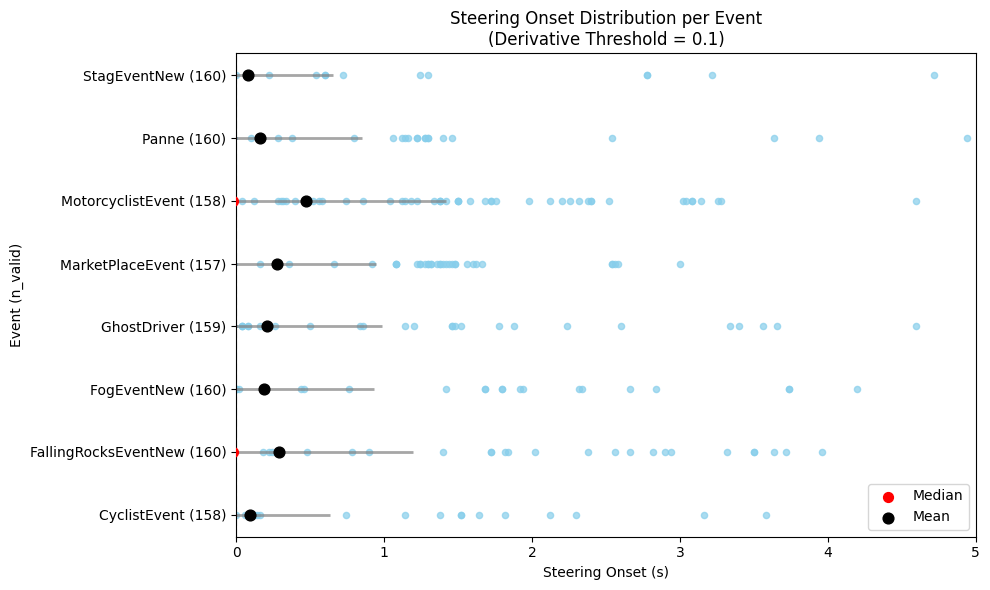

In [58]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ===== USER SETTINGS =====
COLUMN_NAME = "SteeringInput"      # replace with your actual steering column
SMOOTH_WINDOW = 5                 # smoothing window for derivative (must be odd)
POLY_ORDER = 3                     # polynomial order for Savitzky-Golay filter
DERIV_THRESHOLD = 0.1             # minimal derivative value to consider onset (tunable)

# ===== FUNCTIONS =====
def detect_derivative_onset(signal, threshold=DERIV_THRESHOLD):
    """Detect first significant steering movement based on derivative peaks."""
    if len(signal) < SMOOTH_WINDOW:
        return np.nan  # not enough data

    # Smooth and compute derivative
    smooth_signal = savgol_filter(signal, SMOOTH_WINDOW, POLY_ORDER)
    derivative = np.gradient(smooth_signal)

    # Normalize derivative
    max_val = np.nanmax(np.abs(derivative))
    if max_val == 0 or np.isnan(max_val):
        return np.nan
    derivative /= max_val

    # Find first time derivative exceeds threshold
    onset_indices = np.where(np.abs(derivative) > threshold)[0]
    return onset_indices[0] if len(onset_indices) > 0 else np.nan


def extract_event_name(fname):
    """Extract event name between 'segment_around_' and '_nearest'."""
    match = re.search(r'segment_around_(.*?)_nearest', fname)
    return match.group(1) if match else fname


# ===== MAIN LOOP =====
summary = []
all_onsets = []

for fname in sorted(os.listdir(DATA_DIR)):
    if not (fname.startswith("segment_") and fname.endswith(".csv")):
        continue

    event_name = extract_event_name(fname)
    fpath = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(fpath)

    if 'uid' not in df.columns or COLUMN_NAME not in df.columns:
        print(f"⚠️ Skipping {fname}: missing required columns.")
        continue

    event_onsets = []
    uid_counts = df['uid'].value_counts()
    n_total = len(uid_counts)

    for uid, subdf in df.groupby('uid'):
        steering = subdf[COLUMN_NAME].values
        onset_idx = detect_derivative_onset(steering)

        if not np.isnan(onset_idx):
            time_axis_adjusted = np.linspace(-5, 5, len(steering))
            onset_time = time_axis_adjusted[int(onset_idx)]
        else:
            onset_time = np.nan

        event_onsets.append(onset_time)
        all_onsets.append({"event": event_name, "onset_s": onset_time})

    mean_onset = np.nanmean(event_onsets)
    median_onset = np.nanmedian(event_onsets)
    sd_onset = np.nanstd(event_onsets)
    n_valid = np.sum(~np.isnan(event_onsets))

    summary.append({
        "event": event_name,
        "mean_onset_s": mean_onset,
        "median_onset_s": median_onset,
        "sd_onset_s": sd_onset,
        "n_valid": n_valid,
        "n_total": n_total
    })

# ===== SUMMARY TABLE =====
summary_df = pd.DataFrame(summary).sort_values("event").reset_index(drop=True)

print("\n✅ Derivative-based Steering Onset Summary per Event:")
print(summary_df.to_string(index=False))

# --- Save to CSV ---
summary_path = os.path.join(DATA_DIR, "steering_onset_summary_derivative.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\n✅ Summary saved to: {summary_path}")

# ===== PLOTTING =====
all_onsets_df = pd.DataFrame(all_onsets)
all_onsets_df = all_onsets_df[all_onsets_df["event"].isin(summary_df["event"])]
all_onsets_df["event"] = pd.Categorical(all_onsets_df["event"], categories=summary_df["event"], ordered=True)

# --- Compute stats ---
stats = all_onsets_df.groupby("event")["onset_s"].agg(['mean', 'median', 'std']).reset_index()
stats = stats.merge(summary_df[['event', 'n_valid']], on='event')

# --- Labels and Y positions ---
stats['label'] = stats.apply(lambda r: f"{r['event']} ({int(r['n_valid'])})", axis=1)
event_to_y = {event: i for i, event in enumerate(stats['event'])}
all_onsets_df['y_pos'] = all_onsets_df['event'].map(event_to_y)

# --- Plot ---
plt.figure(figsize=(10, 6))

# Scatter raw onsets
plt.scatter(
    all_onsets_df['onset_s'],
    all_onsets_df['y_pos'],
    color='skyblue', s=20, alpha=0.7
)

# Mean (black), Median (red), SD whiskers
for idx, row in stats.iterrows():
    y = idx
    plt.hlines(
        y=y,
        xmin=row['mean'] - row['std'],
        xmax=row['mean'] + row['std'],
        colors='gray', linewidth=2, alpha=0.7
    )
    plt.scatter(row['median'], y, color='red', s=50, zorder=10, label='Median' if idx == 0 else "")
    plt.scatter(row['mean'], y, color='black', s=60, zorder=11, label='Mean' if idx == 0 else "")

plt.axvline(0, color='gray', linestyle='--')
plt.yticks(ticks=range(len(stats)), labels=stats['label'])
plt.xlabel("Steering Onset (s)")
plt.ylabel("Event (n_valid)")
plt.xlim(0, 5)
plt.title(f"Steering Onset Distribution per Event\n(Derivative Threshold = {DERIV_THRESHOLD})")
plt.legend()
plt.tight_layout()
plt.show()


# CRASH


Accident Onset Summary per Event:
               event  total_uids  successful_uids  unsuccessful_uids  crashed_uids  mean_crash_s  median_crash_s  sd_crash_s
        CyclistEvent         159              107                 52             0           NaN             NaN         NaN
FallingRocksEventNew         160               84                 76            18         4.050           4.070       0.413
         FogEventNew         160               48                112            44         3.946           3.830       0.472
         GhostDriver         160               48                112             5         4.108           3.840       0.484
    MarketPlaceEvent         157              120                 37            10         3.858           3.740       0.555
   MotorcyclistEvent         158               85                 73            61         4.789           4.820       0.133
               Panne         160              123                 37            35        

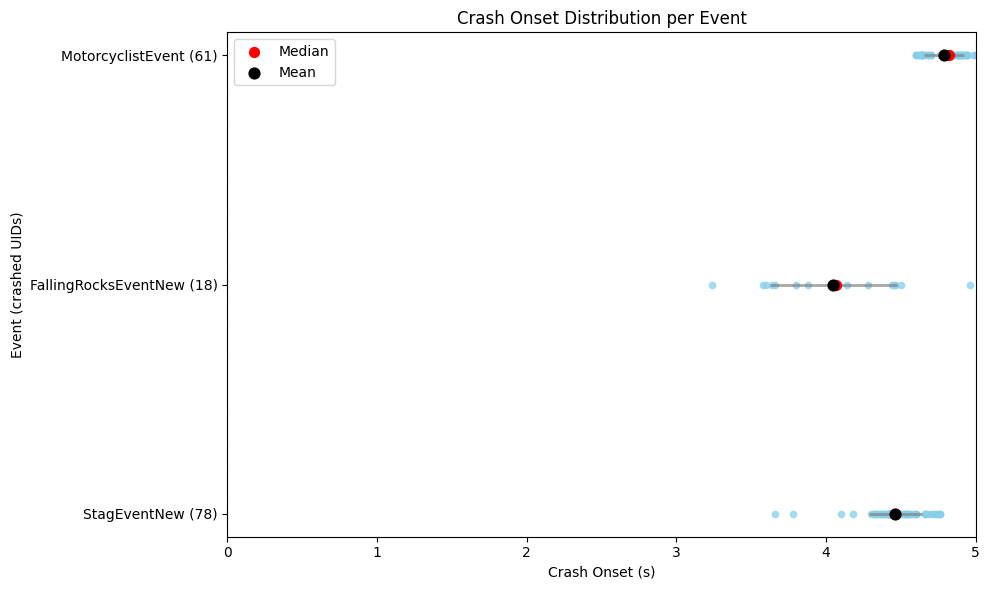

In [118]:

# --- Helper: Extract event name from filename ---
def extract_event_name(fname):
    """Extract the part between 'segment_around_' and '_nearest'."""
    match = re.search(r'segment_around_(.*?)_nearest', fname)
    return match.group(1) if match else fname

summary = []
all_crash_records = []  # will hold individual crash times (for plotting)

# === MAIN LOOP OVER FILES ===
for fname in sorted(os.listdir(DATA_DIR)):
    if not (fname.startswith("segment_") and fname.endswith(".csv")):
        continue

    fpath = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(fpath)

    # Sanity check
    if 'uid' not in df.columns or 'SuccessfulCompletionState' not in df.columns or 'EventName' not in df.columns:
        print(f"⚠️ Skipping {fname}: missing required columns.")
        continue

    event_name = extract_event_name(fname)

    crashed_times = []
    total_uids = df['uid'].nunique()
    successful_uids = 0
    unsuccessful_uids = 0
    crashed_uids = 0

    for uid, subdf in df.groupby('uid'):
        steering_rows = subdf.reset_index(drop=True)
        time_axis = np.linspace(TIME_WINDOW[0], TIME_WINDOW[1], len(steering_rows))

        post0_rows = steering_rows.iloc[250:]  # after time >= 0

        if post0_rows['SuccessfulCompletionState'].iloc[0] == 1:
            successful_uids += 1
            continue
        else:
            unsuccessful_uids += 1
            crash_indices = post0_rows.index[post0_rows['EventName'].values == 'NoEvent'].tolist()
            if crash_indices:
                crashed_uids += 1
                first_crash_idx = crash_indices[0]
                crash_time = time_axis[first_crash_idx]
                crashed_times.append(crash_time)
                all_crash_records.append({"uid": uid, "event": event_name, "crash_time_s": crash_time})

    # Compute stats for this event
    if crashed_times:
        mean_crash = np.mean(crashed_times)
        median_crash = np.median(crashed_times)
        sd_crash = np.std(crashed_times)
    else:
        mean_crash = median_crash = sd_crash = np.nan

    summary.append({
        "event": event_name,
        "total_uids": total_uids,
        "successful_uids": successful_uids,
        "unsuccessful_uids": unsuccessful_uids,
        "crashed_uids": crashed_uids,
        "mean_crash_s": mean_crash,
        "median_crash_s": median_crash,
        "sd_crash_s": sd_crash
    })

# === SUMMARY TABLE ===
summary_df = pd.DataFrame(summary)
print("\nAccident Onset Summary per Event:")
print(summary_df.to_string(index=False))

# Save summary
summary_path = os.path.join(DATA_DIR, "crash_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\n✅ Summary saved to: {summary_path}")

# === PREPARE DATA FOR PLOT ===
all_crash_df = pd.DataFrame(all_crash_records)
if all_crash_df.empty:
    raise ValueError("No crash events recorded — nothing to plot.")


# --- Compute crash counts per event ---
crash_counts = all_crash_df['event'].value_counts().to_dict()

# --- Assign y positions ---
event_to_y = {event: i for i, event in enumerate(event_order)}
all_crash_df['y_pos'] = all_crash_df['event'].map(event_to_y)

# --- Compute stats per event for plot ---
stats = all_crash_df.groupby("event")["crash_time_s"].agg(['mean', 'median', 'std']).reset_index()

# --- Label with crash counts ---
stats['label'] = stats['event'].apply(lambda x: f"{x} ({crash_counts.get(x,0)})")
ordered_labels = [f"{e} ({crash_counts.get(e,0)})" for e in event_order]

# === PLOT ===
plt.figure(figsize=(10, 6))

# scatter individual crash times
plt.scatter(
    all_crash_df['crash_time_s'],
    all_crash_df['y_pos'],
    color='skyblue',
    s=20,
    alpha=0.7
)

# overlay mean, median, and SD whiskers
for _, row in stats.iterrows():
    y = event_to_y.get(row['event'], np.nan)
    if np.isnan(y):
        continue
    plt.hlines(y=y,
               xmin=row['mean'] - row['std'],
               xmax=row['mean'] + row['std'],
               colors='gray',
               linewidth=2,
               alpha=0.7)
    plt.scatter(row['median'], y, color='red', s=50, zorder=10, label='Median' if y==0 else "")
    plt.scatter(row['mean'], y, color='black', s=60, zorder=11, label='Mean' if y==0 else "")

plt.axvline(0, color='gray', linestyle='--')
plt.yticks(ticks=range(len(ordered_labels)), labels=ordered_labels)
plt.xlabel("Crash Onset (s)")
plt.ylabel("Event (crashed UIDs)")
plt.xlim(0, 5)
plt.title("Crash Onset Distribution per Event")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\erene\AppData\Local\Temp\ipykernel_19280\4294328519.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_crash_df['event'] = pd.Categorical(plot_crash_df['event'], categories=event_order, ordered=True)
C:\Users\erene\AppData\Local\Temp\ipykernel_19280\4294328519.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Event", loc='upper right')


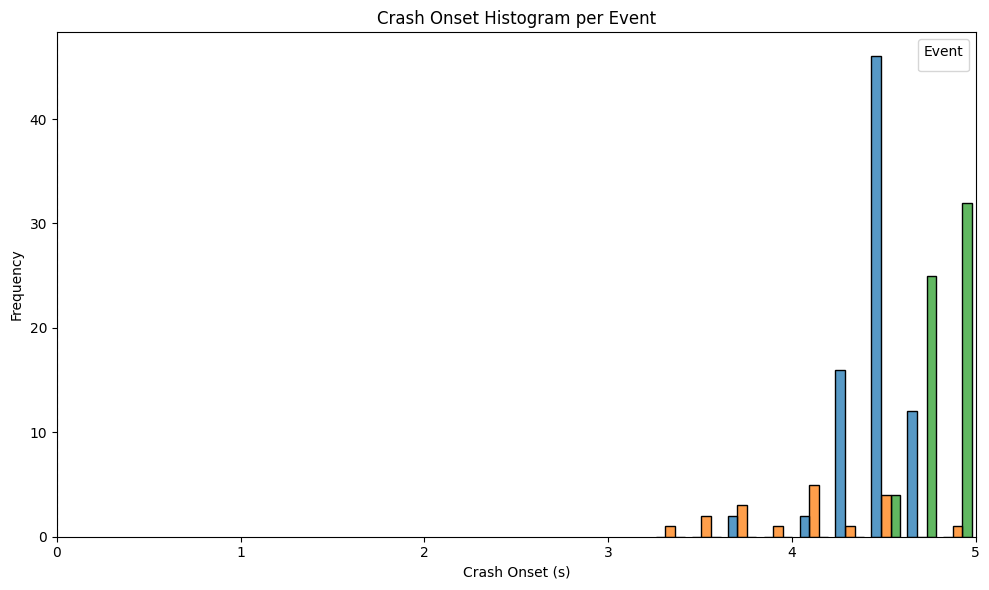

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter crash data to include only events in event_order
plot_crash_df = all_crash_df[all_crash_df['event'].isin(event_order)]

if plot_crash_df.empty:
    raise ValueError("No crash events recorded for the selected events — nothing to plot.")

# Set categorical ordering for events
plot_crash_df['event'] = pd.Categorical(plot_crash_df['event'], categories=event_order, ordered=True)

# Plot histogram of crash times per event
plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_crash_df,
    x="crash_time_s",
    hue="event",
    multiple="dodge",    # separate bars per event
    binwidth=0.2,        # 0.2s bins
    shrink=0.8,
    palette="tab10",
    edgecolor="black"
)

plt.axvline(0, color='gray', linestyle='--')
plt.xlabel("Crash Onset (s)")
plt.ylabel("Frequency")
plt.title("Crash Onset Histogram per Event")
plt.xlim(0, 5)
plt.legend(title="Event", loc='upper right')
plt.tight_layout()
plt.show()


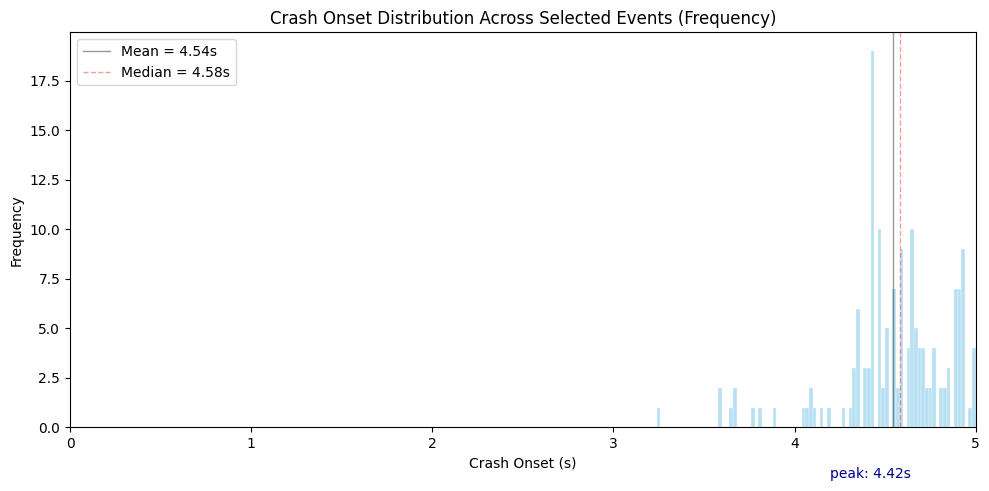

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter crashes to only selected events
aggregate_crash_df = all_crash_df[all_crash_df['event'].isin(event_order)]

if aggregate_crash_df.empty:
    raise ValueError("No crash events recorded for the selected events — nothing to plot.")

# Extract crash times
crash_times = aggregate_crash_df['crash_time_s'].dropna()

# Compute histogram bins and peak
counts, bin_edges = np.histogram(crash_times, bins=250)  # same bin count as RT example
max_idx = np.argmax(counts)
max_freq_crash = (bin_edges[max_idx] + bin_edges[max_idx + 1]) / 2

# Compute summary stats
mean_crash = crash_times.mean()
median_crash = crash_times.median()
sd_crash = crash_times.std()

plt.figure(figsize=(10, 5))

bins = np.linspace(0, 5, 251)  # 250 bins → 0.02s width

# --- Frequency histogram ---
sns.histplot(
    crash_times,
    bins=bins,
    color='skyblue',
    stat='count',   # frequency on y-axis
    kde=False,
    alpha=0.6,
    edgecolor='white',
)

# --- Overlay mean ± SD and median ---
plt.axvline(mean_crash, color='black', linestyle='-', linewidth=1, alpha=0.4, label=f"Mean = {mean_crash:.2f}s")
plt.axvline(median_crash, color='red', linestyle='--', linewidth=1, alpha=0.4, label=f"Median = {median_crash:.2f}s")

# --- Annotate peak frequency ---
plt.text(
    max_freq_crash, -2,  # slightly below x-axis
    f"peak: {max_freq_crash:.2f}s",
    ha='center',
    va='top',
    fontsize=10,
    color='darkblue'
)

plt.xlabel("Crash Onset (s)")
plt.ylabel("Frequency")
plt.title("Crash Onset Distribution Across Selected Events (Frequency)")
plt.xlim(0, 5)
plt.legend()
plt.tight_layout()
plt.show()
